# LangGraph Router with Message-First Structured Symptom Specialist

This notebook demonstrates a clean LangGraph workflow for two kinds of clinical screening requests:

1. the control model routes each user request to either **instructions** or **symptom screening**;
2. symptom requests enter a dedicated tool-calling subgraph;
3. the tool invokes a structured symptom specialist with a training-aligned prompt;
4. the specialist returns strict JSON with the contract `support_status`, `candidate_diseases`, and `recommended_exams_tests`;
5. the control model produces the final natural-language answer;
6. the final transcript is rendered directly from LangChain messages with `pretty_print()`.

The notebook stays compatible with the existing environment variables:

- `SCREENING_AGENT_CONTROL_*` for the control model;
- `SCREENING_AGENT_CLINICAL_*` for the structured symptom specialist;
- `SCREENING_AGENT_GGUF_MODEL_PATH` for the local GGUF runtime.

Synthetic patient cases are kept in-memory so the notebook stays standalone and deterministic.

In [1]:
from __future__ import annotations

from collections.abc import Callable, Mapping, Sequence
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Literal, cast
import json
import os
import uuid

from dotenv import load_dotenv
from IPython.display import Image, Markdown, display
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import BaseTool, tool
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from pydantic import BaseModel, Field, SecretStr, field_validator

In [2]:
ChatBackendKind = Literal["openai", "openrouter", "openai_compatible"]
ClinicalRuntimeKind = Literal["openai", "openrouter", "openai_compatible", "gguf"]
Destination = Literal["symptom_flow", "instructions_specialist"]


@dataclass(frozen=True)
class NotebookChatSettings:
    """Configuration for a chat-model-backed notebook runtime."""

    backend: ChatBackendKind
    model: str
    base_url: str | None
    api_key: str | None
    temperature: float


@dataclass(frozen=True)
class NotebookClinicalSettings:
    """Configuration for the structured symptom specialist runtime."""

    backend: ClinicalRuntimeKind
    model: str | None
    base_url: str | None
    api_key: str | None
    gguf_model_path: Path | None
    temperature: float


@dataclass(frozen=True)
class NotebookRuntimeSettings:
    """Top-level runtime settings used by the notebook graph."""

    control_model: NotebookChatSettings
    symptom_runtime: NotebookClinicalSettings


def _load_env_file(env_path: Path | None = None) -> Path:
    """Load the notebook `.env` file and return its resolved path.

    Args:
        env_path: Optional explicit path to the `.env` file.

    Returns:
        The resolved `.env` path.

    Raises:
        FileNotFoundError: If the `.env` file does not exist.
    """

    resolved_env_path = env_path or Path.cwd() / ".env"
    if not resolved_env_path.exists():
        raise FileNotFoundError(f"Could not find .env file at {resolved_env_path}")
    load_dotenv(resolved_env_path, override=True)
    return resolved_env_path


def _read_chat_backend(value: str) -> ChatBackendKind:
    """Validate a chat backend value.

    Args:
        value: Raw backend value from the environment.

    Returns:
        A validated chat backend literal.

    Raises:
        ValueError: If the backend is not supported.
    """

    normalized_value = value.strip().lower()
    if normalized_value not in {"openai", "openrouter", "openai_compatible"}:
        raise ValueError(
            "Chat backend must be 'openai', 'openrouter', or 'openai_compatible'."
        )
    return cast(ChatBackendKind, normalized_value)


def _read_clinical_backend(value: str) -> ClinicalRuntimeKind:
    """Validate a clinical runtime value.

    Args:
        value: Raw backend value from the environment.

    Returns:
        A validated clinical runtime literal.

    Raises:
        ValueError: If the backend is not supported.
    """

    normalized_value = value.strip().lower()
    if normalized_value not in {"openai", "openrouter", "openai_compatible", "gguf"}:
        raise ValueError(
            "Clinical backend must be 'openai', 'openrouter', 'openai_compatible', or 'gguf'."
        )
    return cast(ClinicalRuntimeKind, normalized_value)


def _read_float_env(name: str, default: float) -> float:
    """Read a floating-point environment variable.

    Args:
        name: Environment variable name.
        default: Default value when the variable is missing.

    Returns:
        The parsed floating-point value.
    """

    raw_value = os.getenv(name)
    if raw_value is None or not raw_value.strip():
        return default
    return float(raw_value)


def load_notebook_runtime_settings(env_path: Path | None = None) -> NotebookRuntimeSettings:
    """Load all notebook runtimes from the current `.env` file.

    Args:
        env_path: Optional explicit path to the `.env` file.

    Returns:
        The runtime settings used by the control model and symptom specialist.

    Raises:
        ValueError: If required model configuration is missing.
    """

    _load_env_file(env_path)

    control_model_name = os.getenv("SCREENING_AGENT_CONTROL_MODEL", "").strip()
    if not control_model_name:
        raise ValueError("SCREENING_AGENT_CONTROL_MODEL must be set in the .env file.")

    control_settings = NotebookChatSettings(
        backend=_read_chat_backend(
            os.getenv("SCREENING_AGENT_CONTROL_BACKEND", "openai_compatible")
        ),
        model=control_model_name,
        base_url=os.getenv("SCREENING_AGENT_CONTROL_BASE_URL"),
        api_key=os.getenv("SCREENING_AGENT_CONTROL_API_KEY"),
        temperature=_read_float_env("SCREENING_AGENT_CONTROL_TEMPERATURE", 0.0),
    )

    raw_clinical_model = os.getenv("SCREENING_AGENT_CLINICAL_MODEL")
    raw_gguf_model_path = os.getenv("SCREENING_AGENT_GGUF_MODEL_PATH")
    symptom_runtime = NotebookClinicalSettings(
        backend=_read_clinical_backend(
            os.getenv("SCREENING_AGENT_CLINICAL_BACKEND", "openai_compatible")
        ),
        model=raw_clinical_model.strip() if raw_clinical_model and raw_clinical_model.strip() else None,
        base_url=os.getenv("SCREENING_AGENT_CLINICAL_BASE_URL") or control_settings.base_url,
        api_key=os.getenv("SCREENING_AGENT_CLINICAL_API_KEY") or control_settings.api_key,
        gguf_model_path=Path(raw_gguf_model_path) if raw_gguf_model_path and raw_gguf_model_path.strip() else None,
        temperature=_read_float_env("SCREENING_AGENT_CLINICAL_TEMPERATURE", 0.0),
    )

    return NotebookRuntimeSettings(
        control_model=control_settings,
        symptom_runtime=symptom_runtime,
    )


def build_chat_model(settings: NotebookChatSettings) -> BaseChatModel:
    """Create a chat model from notebook settings.

    Args:
        settings: Chat runtime settings.

    Returns:
        A configured LangChain chat model.

    Raises:
        ValueError: If an OpenAI-compatible backend is missing its base URL.
    """

    if settings.backend == "openrouter":
        from langchain_openrouter import ChatOpenRouter

        return ChatOpenRouter(
            model=settings.model,
            api_key=SecretStr(settings.api_key) if settings.api_key else None,
            temperature=settings.temperature,
        )

    model_kwargs: dict[str, Any] = {
        "model": settings.model,
        "temperature": settings.temperature,
    }
    if settings.api_key:
        model_kwargs["api_key"] = SecretStr(settings.api_key)

    if settings.backend == "openai_compatible":
        if not settings.base_url:
            raise ValueError(
                "SCREENING_AGENT_CONTROL_BASE_URL must be set when using the openai_compatible backend."
            )
        model_kwargs["base_url"] = settings.base_url

    return ChatOpenAI(**model_kwargs)

In [3]:
VALID_SUPPORT_STATUSES: tuple[str, str] = ("supported", "inconclusive")


class ClinicalScreeningOutput(BaseModel):
    """Structured output emitted by the symptom specialist."""

    support_status: Literal["supported", "inconclusive"] = Field(
        description="Whether the current evidence strongly supports a shortlist or remains inconclusive."
    )
    candidate_diseases: list[str] = Field(
        min_length=1,
        description="Ordered disease candidates, from strongest to weakest match.",
    )
    recommended_exams_tests: list[str] = Field(
        min_length=1,
        description="Ordered exams or tests that could help confirm or clarify the differential.",
    )

    @field_validator("support_status", mode="before")
    @classmethod
    def _normalize_support_status(cls, value: Any) -> str:
        """Normalize and validate the support status string.

        Args:
            value: Raw support status emitted by the model.

        Returns:
            The canonical lowercase support status.

        Raises:
            ValueError: If the status is not part of the accepted contract.
        """

        normalized_value = str(value).strip().lower()
        if normalized_value not in VALID_SUPPORT_STATUSES:
            raise ValueError(
                f"support_status must be one of {VALID_SUPPORT_STATUSES!r}; got {normalized_value!r}."
            )
        return normalized_value

    @field_validator("candidate_diseases", "recommended_exams_tests", mode="before")
    @classmethod
    def _normalize_string_list(cls, value: Any) -> list[str]:
        """Normalize ordered string lists and remove duplicates.

        Args:
            value: Raw list value emitted by the model.

        Returns:
            A cleaned list with unique non-empty strings.

        Raises:
            TypeError: If the raw value is not a list.
            ValueError: If the cleaned list becomes empty.
        """

        if not isinstance(value, list):
            raise TypeError("Expected a list of strings.")

        cleaned_values = [str(item).strip() for item in value if str(item).strip()]
        normalized_values = unique_preserve(cleaned_values)
        if not normalized_values:
            raise ValueError("The list must contain at least one non-empty string.")
        return normalized_values


SpecialistInvoker = Callable[[str, str], ClinicalScreeningOutput]


def unique_preserve(items: Sequence[str]) -> list[str]:
    """Return unique strings while preserving the first occurrence order.

    Args:
        items: Ordered string sequence.

    Returns:
        A deduplicated list with stable ordering.
    """

    seen: set[str] = set()
    unique_items: list[str] = []
    for item in items:
        if item in seen:
            continue
        seen.add(item)
        unique_items.append(item)
    return unique_items


@dataclass(frozen=True)
class SyntheticPatientCase:
    """Synthetic patient details used to simulate an active notebook context."""

    key: str
    display_name: str
    age_description: str
    background: str
    chronic_conditions: tuple[str, ...]
    medications: tuple[str, ...]
    allergies: tuple[str, ...]
    current_context: str


SYNTHETIC_PATIENT_CASES: dict[str, SyntheticPatientCase] = {
    "maria_teacher": SyntheticPatientCase(
        key="maria_teacher",
        display_name="Maria S.",
        age_description="34-year-old school teacher",
        background="Lives with two children and works in a crowded classroom.",
        chronic_conditions=("mild intermittent asthma",),
        medications=("albuterol inhaler as needed",),
        allergies=("penicillin",),
        current_context="Reports that several students at school have had fever and sore throat this week.",
    ),
    "joao_retired_driver": SyntheticPatientCase(
        key="joao_retired_driver",
        display_name="João P.",
        age_description="67-year-old retired bus driver",
        background="Lives with his spouse and recently attended a large family gathering.",
        chronic_conditions=("type 2 diabetes", "hypertension", "hyperlipidemia"),
        medications=("metformin", "losartan", "atorvastatin"),
        allergies=("no known drug allergies",),
        current_context="Mentions reduced appetite and mild fatigue after a weekend with many relatives indoors.",
    ),
    "ana_grad_student": SyntheticPatientCase(
        key="ana_grad_student",
        display_name="Ana C.",
        age_description="26-year-old graduate student",
        background="Recently returned from a short domestic trip and has been sleeping poorly.",
        chronic_conditions=("migraine", "iron deficiency"),
        medications=("sumatriptan as needed", "ferrous sulfate"),
        allergies=("shellfish",),
        current_context="Says that stress has been high for the last two weeks because of exams and travel.",
    ),
}


def get_patient_case(case_key: str) -> SyntheticPatientCase:
    """Return one synthetic patient case by key.

    Args:
        case_key: Dictionary key for the patient case.

    Returns:
        The matching synthetic patient case.

    Raises:
        KeyError: If the requested case does not exist.
    """

    if case_key not in SYNTHETIC_PATIENT_CASES:
        available_keys = ", ".join(sorted(SYNTHETIC_PATIENT_CASES))
        raise KeyError(f"Unknown patient case {case_key!r}. Available cases: {available_keys}")
    return SYNTHETIC_PATIENT_CASES[case_key]


def render_active_patient_context(patient_case: SyntheticPatientCase) -> str:
    """Render the synthetic patient into a compact clinical context block.

    Args:
        patient_case: Synthetic patient metadata.

    Returns:
        A multi-line plain-text context block.
    """

    chronic_conditions = ", ".join(patient_case.chronic_conditions)
    medications = ", ".join(patient_case.medications)
    allergies = ", ".join(patient_case.allergies)
    return (
        f"Patient: {patient_case.display_name}\n"
        f"Profile: {patient_case.age_description}\n"
        f"Background: {patient_case.background}\n"
        f"Chronic conditions: {chronic_conditions}\n"
        f"Current medications: {medications}\n"
        f"Allergies: {allergies}\n"
        f"Current context: {patient_case.current_context}"
    )


def format_structured_payload(payload: ClinicalScreeningOutput) -> str:
    """Format a structured payload as pretty JSON for prompts or display.

    Args:
        payload: Structured specialist output.

    Returns:
        A pretty-printed JSON string.
    """

    return json.dumps(payload.model_dump(), ensure_ascii=False, indent=2)

In [5]:
TRAINING_SYSTEM_PROMPT = """
You are a clinical screening assistant focused on symptom analysis.

Your job is to:
- interpret the user's complaint in context;
- recommend relevant confirmatory exams or next assessment steps;

Output requirements:
- Respond in the same language as the user, eg., English, Spanish, French.
- Produce a structured internal result in JSON format.
- Return only the JSON object.
- Use exactly these keys in the JSON object: support_status, candidate_diseases, recommended_exams_tests.
""".strip()


def build_training_style_clinical_input(clinical_request: str, active_patient_context: str) -> str:
    """Render the symptom-specialist user message using the training-aligned layout.

    Args:
        clinical_request: Original symptom question from the user.
        active_patient_context: Current synthetic patient context shown to the specialist.

    Returns:
        The formatted user message expected by the structured specialist.
    """

    return (
        "Clinical request:\n"
        f"{clinical_request.strip()}\n\n"
        "Active patient context:\n"
        f"{active_patient_context.strip()}"
    )


def extract_json_object(text: str) -> str:
    """Extract the first JSON object found in a text response.

    Args:
        text: Raw text that may contain a JSON object.

    Returns:
        The substring containing the JSON object.

    Raises:
        ValueError: If no JSON object can be found.
    """

    start_index = text.find("{")
    end_index = text.rfind("}")
    if start_index == -1 or end_index == -1 or end_index < start_index:
        raise ValueError("The model response did not contain a JSON object.")
    return text[start_index : end_index + 1]


def parse_specialist_output(raw_text: str) -> ClinicalScreeningOutput:
    """Parse and validate the structured output emitted by the symptom specialist.

    Args:
        raw_text: Raw text response that should contain the contract JSON.

    Returns:
        A validated structured output instance.

    Raises:
        ValueError: If the text does not contain a valid JSON object.
    """

    parsed_payload = json.loads(extract_json_object(raw_text.strip()))
    return ClinicalScreeningOutput.model_validate(parsed_payload)


def _extract_raw_content_text(content: Any) -> str:
    """Normalize a raw backend content payload into plain text.

    Args:
        content: Raw content payload returned by a non-LangChain backend.

    Returns:
        A plain-text representation of the content.
    """

    if isinstance(content, str):
        return content.strip()
    if isinstance(content, list):
        parts: list[str] = []
        for item in content:
            if isinstance(item, str) and item.strip():
                parts.append(item.strip())
            elif isinstance(item, Mapping):
                text_value = item.get("text") or item.get("content")
                if text_value:
                    parts.append(str(text_value).strip())
        return "\n".join(part for part in parts if part)
    return str(content).strip()


def _extract_gguf_message_content(completion: Any) -> str:
    """Extract assistant text content from a `llama-cpp-python` chat completion.

    Args:
        completion: Raw object returned by `create_chat_completion(...)`.

    Returns:
        The assistant message text.

    Raises:
        ValueError: If the completion structure is missing the assistant message.
    """

    if not isinstance(completion, Mapping):
        raise ValueError("GGUF completion did not return a mapping payload.")

    choices = completion.get("choices")
    if not isinstance(choices, list) or not choices:
        raise ValueError("GGUF completion did not return any choices.")

    first_choice = choices[0]
    if not isinstance(first_choice, Mapping):
        raise ValueError("GGUF completion choice has an unexpected format.")

    message = first_choice.get("message")
    if not isinstance(message, Mapping):
        raise ValueError("GGUF completion did not contain a chat message.")

    return _extract_raw_content_text(message.get("content", ""))


def build_gguf_specialist_invoker(settings: NotebookClinicalSettings) -> tuple[SpecialistInvoker, str]:
    """Create a GGUF-backed specialist invoker with schema-constrained decoding.

    Args:
        settings: Clinical runtime settings for the GGUF-backed specialist.

    Returns:
        A tuple with the invoker function and a short runtime label.

    Raises:
        ImportError: If `llama-cpp-python` is unavailable.
        ValueError: If the GGUF model path is missing.
    """

    if settings.gguf_model_path is None:
        raise ValueError(
            "SCREENING_AGENT_GGUF_MODEL_PATH must be set when using the gguf backend."
        )

    try:
        from llama_cpp import Llama, LlamaGrammar
    except ImportError as error:
        raise ImportError(
            "Install `llama-cpp-python` in the notebook environment to use the gguf backend."
        ) from error

    gguf_llm = Llama(
        model_path=str(settings.gguf_model_path),
        n_ctx=4096,
        chat_format="chatml",
        verbose=False,
    )
    response_format: Any = {
        "type": "json_object",
        "schema": ClinicalScreeningOutput.model_json_schema(),
    }

    def invoke_specialist(clinical_request: str, active_patient_context: str) -> ClinicalScreeningOutput:
        """Run one structured specialist inference against the local GGUF model.

        Args:
            clinical_request: Symptom-focused user request.
            active_patient_context: Current patient context string.

        Returns:
            The validated structured specialist output.

        Raises:
            RuntimeError: If schema-constrained decoding fails twice.
        """

        messages: Any = [
            {"role": "system", "content": TRAINING_SYSTEM_PROMPT},
            {
                "role": "user",
                "content": build_training_style_clinical_input(
                    clinical_request,
                    active_patient_context,
                ),
            },
        ]

        try:
            completion = gguf_llm.create_chat_completion(
                messages=messages,
                temperature=settings.temperature,
                response_format=response_format,
            )
            return parse_specialist_output(_extract_gguf_message_content(completion))
        except Exception as first_error:
            grammar = LlamaGrammar.from_json_schema(
                json.dumps(ClinicalScreeningOutput.model_json_schema())
            )
            try:
                completion = gguf_llm.create_chat_completion(
                    messages=messages,
                    temperature=settings.temperature,
                    grammar=grammar,
                )
                return parse_specialist_output(_extract_gguf_message_content(completion))
            except Exception as second_error:
                raise RuntimeError(
                    "GGUF structured generation failed with both response_format and grammar fallback. "
                    f"Initial error: {first_error}"
                ) from second_error

    return invoke_specialist, f"gguf:{settings.gguf_model_path.name}"


def build_remote_specialist_invoker(
    settings: NotebookClinicalSettings,
) -> tuple[SpecialistInvoker, str]:
    """Create a remote structured specialist invoker using the clinical runtime settings.

    Args:
        settings: Clinical runtime settings for remote backends.

    Returns:
        A tuple with the invoker function and a short runtime label.

    Raises:
        ValueError: If the clinical model name is missing.
    """

    if not settings.model:
        raise ValueError("SCREENING_AGENT_CLINICAL_MODEL must be set for remote clinical backends.")

    clinical_chat_settings = NotebookChatSettings(
        backend=cast(ChatBackendKind, settings.backend),
        model=settings.model,
        base_url=settings.base_url,
        api_key=settings.api_key,
        temperature=settings.temperature,
    )
    clinical_llm = build_chat_model(clinical_chat_settings)

    def invoke_specialist(clinical_request: str, active_patient_context: str) -> ClinicalScreeningOutput:
        """Run one structured specialist inference against a remote chat backend.

        Args:
            clinical_request: Symptom-focused user request.
            active_patient_context: Current patient context string.

        Returns:
            The validated structured specialist output.
        """

        response = clinical_llm.invoke(
            [
                SystemMessage(content=TRAINING_SYSTEM_PROMPT),
                HumanMessage(
                    content=build_training_style_clinical_input(
                        clinical_request,
                        active_patient_context,
                    )
                ),
            ]
        )
        return parse_specialist_output(response.text)

    return invoke_specialist, f"{settings.backend}:{settings.model}"


def build_symptom_specialist_invoker(
    settings: NotebookClinicalSettings,
) -> tuple[SpecialistInvoker, str]:
    """Create the structured symptom specialist invoker for the selected backend.

    Args:
        settings: Clinical runtime settings.

    Returns:
        A tuple with the invoker function and a short runtime label.
    """

    if settings.backend == "gguf":
        return build_gguf_specialist_invoker(settings)
    return build_remote_specialist_invoker(settings)

In [6]:
ROUTER_SYSTEM_PROMPT = """
You are a routing assistant for a simplified clinical screening demo.
Choose exactly one destination.

Route to `symptom_flow` when the user asks about symptoms, triage, possible causes, warning signs, or which exams might help.
Route to `instructions_specialist` when the user asks how to use the assistant, which details to provide, or how to phrase a request.
Return the most appropriate destination for the current question.
""".strip()

INSTRUCTIONS_SPECIALIST_PROMPT = """
You are the control model for a clinical screening notebook demo.
Explain how the user can ask a better question.
Suggest the most useful details to include, such as age range, timeline, severity, triggers, associated symptoms, and relevant medical history.
Keep the answer concise, practical, and patient-friendly.
""".strip()

SYMPTOM_TOOL_CALL_SYSTEM_PROMPT = """
You are orchestrating a structured symptom specialist inside a LangGraph workflow.
Call the tool `{tool_name}` exactly once.
Pass the original symptom question as `clinical_request`.
Pass the full active patient context as `active_patient_context`.
Do not answer the user directly in this node.
""".strip()

FINAL_RENDER_SYSTEM_PROMPT = """
You are an assistant for professional healthcare providers that summarizes the output of a structured symptom specialist about a patient's condition.
Write a cautious, plain-language answer for the user.
Use the structured specialist JSON as the source of truth.
Do not claim a definitive diagnosis.
Acknowledge uncertainty when `support_status` is `inconclusive`.
Summarize the most relevant candidate diseases and recommend the listed exams/tests.
Close with an educational safety note that urgent or worsening symptoms deserve in-person care.
""".strip()


class NotebookState(MessagesState):
    """Graph state for the message-first notebook workflow."""

    active_patient_key: str
    active_patient_display_name: str
    active_patient_context: str
    route: Destination | None
    router_rationale: str | None
    specialist_output: ClinicalScreeningOutput | None


class RouteDecision(BaseModel):
    """Structured router decision with two valid destinations."""

    destination: Destination = Field(
        description="The branch that should continue the user request."
    )
    rationale: str = Field(description="A short explanation for the routing choice.")


def get_latest_human_message(messages: Sequence[BaseMessage]) -> HumanMessage:
    """Return the newest human message from a message sequence.

    Args:
        messages: Ordered message history.

    Returns:
        The most recent human message.

    Raises:
        ValueError: If the sequence contains no human message.
    """

    for message in reversed(messages):
        if isinstance(message, HumanMessage):
            return message
    raise ValueError("The graph expected at least one human message in state.")


def get_latest_human_message_text(messages: Sequence[BaseMessage]) -> str:
    """Return the text content of the newest human message.

    Args:
        messages: Ordered message history.

    Returns:
        The newest human message text.
    """

    return get_latest_human_message(messages).text


def get_latest_tool_message(messages: Sequence[BaseMessage]) -> ToolMessage:
    """Return the newest tool message from a message sequence.

    Args:
        messages: Ordered message history.

    Returns:
        The most recent tool message.

    Raises:
        ValueError: If the sequence contains no tool message.
    """

    for message in reversed(messages):
        if isinstance(message, ToolMessage):
            return message
    raise ValueError("The symptom flow expected a tool result but none was found.")


def get_last_final_ai_message(messages: Sequence[BaseMessage]) -> AIMessage | None:
    """Return the newest AI message that is not a tool-call planner message.

    Args:
        messages: Ordered message history.

    Returns:
        The newest final-answer style AI message, if present.
    """

    for message in reversed(messages):
        if isinstance(message, AIMessage) and not message.tool_calls:
            return message
    return None

In [7]:
def invoke_router_fallback(llm: BaseChatModel, question: str) -> RouteDecision:
    """Run a JSON-prompt fallback when native structured output is unavailable.

    Args:
        llm: Router model used by the graph.
        question: User question to classify.

    Returns:
        A validated route decision.
    """

    fallback_system_prompt = f"""{ROUTER_SYSTEM_PROMPT}

Return only a JSON object with this schema:
{{
  "destination": "symptom_flow" | "instructions_specialist",
  "rationale": "short explanation"
}}
""".strip()
    response = llm.invoke(
        [
            SystemMessage(content=fallback_system_prompt),
            HumanMessage(content=question),
        ]
    )

    if response.text in {"symptom_flow", "instructions_specialist"}:
        return RouteDecision(
            destination=cast(Destination, response.text),
            rationale="Fallback plain-text route",
        )

    return RouteDecision.model_validate_json(extract_json_object(response.text))


def build_router_node(
    llm: BaseChatModel,
) -> Callable[[NotebookState], dict[str, Destination | str]]:
    """Create a router node that writes the chosen destination to state.

    Args:
        llm: Router model used across the graph.

    Returns:
        A LangGraph node function for route selection.
    """

    structured_router = llm.with_structured_output(RouteDecision)

    def router_node(state: NotebookState) -> dict[str, Destination | str]:
        """Classify the current question into one of the notebook branches.

        Args:
            state: Current graph state.

        Returns:
            A partial state update containing the route and rationale.
        """

        question = get_latest_human_message_text(state["messages"])
        router_messages = [
            SystemMessage(content=ROUTER_SYSTEM_PROMPT),
            HumanMessage(content=question),
        ]
        try:
            decision = RouteDecision.model_validate(
                structured_router.invoke(router_messages)
            )
        except Exception:
            decision = invoke_router_fallback(llm, question)

        print(f"Router response: {decision}")
        return {
            "route": decision.destination,
            "router_rationale": decision.rationale,
        }

    return router_node


def build_symptom_specialist_tool(invoker: SpecialistInvoker) -> BaseTool:
    """Create the notebook-local tool that wraps the structured symptom specialist.

    Args:
        invoker: Backend-specific specialist invoker.

    Returns:
        A LangChain tool compatible with `ToolNode` execution.
    """

    @tool
    def run_symptom_specialist(
        clinical_request: str,
        active_patient_context: str,
    ) -> str:
        """Run the structured symptom specialist and return validated JSON.

        Args:
            clinical_request: Symptom-focused user request.
            active_patient_context: Current active patient context.

        Returns:
            A compact JSON string with the specialist contract.
        """

        payload = invoker(clinical_request, active_patient_context)
        return json.dumps(payload.model_dump(), ensure_ascii=False)

    return cast(BaseTool, run_symptom_specialist)


def build_symptom_tool_call_node(
    control_llm: BaseChatModel,
    symptom_tool: BaseTool,
) -> Callable[[NotebookState], dict[str, list[BaseMessage]]]:
    """Create the control-model node that emits the specialist tool call.

    Args:
        control_llm: Control model that decides the tool invocation arguments.
        symptom_tool: Wrapped structured specialist tool.

    Returns:
        A LangGraph node function that appends one AI tool-call message.
    """

    llm_with_tools = control_llm.bind_tools([symptom_tool], tool_choice=symptom_tool.name)

    def tool_call_node(state: NotebookState) -> dict[str, list[BaseMessage]]:
        """Request the control model to call the symptom specialist tool once.

        Args:
            state: Current graph state.

        Returns:
            A partial state update containing the AI tool-call message.
        """

        clinical_request = get_latest_human_message_text(state["messages"])
        planning_messages = [
            SystemMessage(
                content=SYMPTOM_TOOL_CALL_SYSTEM_PROMPT.format(tool_name=symptom_tool.name)
            ),
            HumanMessage(
                content=(
                    "Original symptom question:\n"
                    f"{clinical_request}\n\n"
                    "Active patient context:\n"
                    f"{state['active_patient_context']}"
                )
            ),
        ]
        tool_call_payload = {
            "name": symptom_tool.name,
            "args": {
                "clinical_request": clinical_request,
                "active_patient_context": state["active_patient_context"],
            },
            "id": f"call_{uuid.uuid4().hex[:12]}",
            "type": "tool_call",
        }

        try:
            response = llm_with_tools.invoke(planning_messages)
        except Exception as error:
            print(
                "Control model failed to call the tool. Falling back to a manual tool call message. "
                f"Error: {error}"
            )
            response = AIMessage(content="", tool_calls=[tool_call_payload])

        if not response.tool_calls:
            print("Control model did not emit a tool call. Falling back to a manual tool call message.")
            response = AIMessage(content="", tool_calls=[tool_call_payload])
        return {"messages": [response]}

    return tool_call_node


def capture_specialist_payload(
    state: NotebookState,
) -> dict[str, ClinicalScreeningOutput]:
    """Capture the tool result and persist the parsed structured payload.

    Args:
        state: Current graph state after the tool node ran.

    Returns:
        A partial state update containing the parsed payload.
    """

    tool_message = get_latest_tool_message(state["messages"])
    payload = parse_specialist_output(tool_message.text)
    return {"specialist_output": payload}


def build_instructions_node(
    control_llm: BaseChatModel,
) -> Callable[[NotebookState], dict[str, list[BaseMessage]]]:
    """Create the instructions branch node rendered by the control model.

    Args:
        control_llm: Control model used for the instructions answer.

    Returns:
        A LangGraph node function that appends the final AI answer.
    """

    def instructions_node(state: NotebookState) -> dict[str, list[BaseMessage]]:
        """Answer an instructions-oriented question.

        Args:
            state: Current graph state.

        Returns:
            A partial state update containing the control-model answer message.
        """

        question = get_latest_human_message_text(state["messages"])
        response = control_llm.invoke(
            [
                SystemMessage(content=INSTRUCTIONS_SPECIALIST_PROMPT),
                HumanMessage(content=question),
            ]
        )
        return {"messages": [response]}

    return instructions_node


def build_final_render_node(
    control_llm: BaseChatModel,
) -> Callable[[NotebookState], dict[str, list[BaseMessage]]]:
    """Create the final control-model rendering node for symptom results.

    Args:
        control_llm: Control model used for the final answer.

    Returns:
        A LangGraph node function that appends the final AI answer.
    """

    def final_render_node(state: NotebookState) -> dict[str, list[BaseMessage]]:
        """Transform structured symptom JSON into a final explanation.

        Args:
            state: Current graph state.

        Returns:
            A partial state update containing the final answer message.

        Raises:
            ValueError: If the structured specialist output is missing.
        """

        specialist_output = state.get("specialist_output")
        if specialist_output is None:
            raise ValueError("The final renderer requires `specialist_output` in state.")

        question = get_latest_human_message_text(state["messages"])
        response = control_llm.invoke(
            [
                SystemMessage(content=FINAL_RENDER_SYSTEM_PROMPT),
                HumanMessage(
                    content=(
                        "Original user question:\n"
                        f"{question}\n\n"
                        "Active patient context:\n"
                        f"{state['active_patient_context']}\n\n"
                        "Structured specialist JSON:\n"
                        f"{format_structured_payload(specialist_output)}"
                    )
                ),
            ]
        )
        return {"messages": [response]}

    return final_render_node

In [8]:
def route_from_router(state: NotebookState) -> Destination:
    """Return the next node name based on the router output.

    Args:
        state: Current graph state.

    Returns:
        The chosen branch node name.

    Raises:
        ValueError: If the router route is missing.
    """

    route = state.get("route")
    if route is None:
        raise ValueError("The router must set `route` before conditional routing runs.")
    return cast(Destination, route)


def build_symptom_flow_subgraph(
    control_llm: BaseChatModel,
    symptom_tool: BaseTool,
) -> Any:
    """Build the symptom subgraph that performs tool calling and payload capture.

    Args:
        control_llm: Control model responsible for emitting the tool call.
        symptom_tool: Structured specialist tool executed by `ToolNode`.

    Returns:
        A compiled LangGraph subgraph.
    """

    builder: Any = StateGraph(NotebookState)
    builder.add_node("plan_tool_call", build_symptom_tool_call_node(control_llm, symptom_tool))
    builder.add_node("tools", ToolNode([symptom_tool]))
    builder.add_node("capture_specialist_payload", capture_specialist_payload)
    builder.add_edge(START, "plan_tool_call")
    builder.add_conditional_edges("plan_tool_call", tools_condition)
    builder.add_edge("tools", "capture_specialist_payload")
    builder.add_edge("capture_specialist_payload", END)
    return builder.compile()


def build_router_demo_graph_v3(
    *,
    control_llm: BaseChatModel,
    symptom_tool: BaseTool,
) -> Any:
    """Build and compile the router graph with the structured symptom subgraph.

    Args:
        control_llm: Control model used for routing, tool orchestration, and final rendering.
        symptom_tool: Wrapped structured symptom tool executed inside the subgraph.

    Returns:
        A compiled LangGraph workflow.
    """

    symptom_subgraph = build_symptom_flow_subgraph(control_llm, symptom_tool)

    builder: Any = StateGraph(NotebookState)
    builder.add_node("router", build_router_node(control_llm))
    builder.add_node("instructions_specialist", build_instructions_node(control_llm))
    builder.add_node("symptom_flow", symptom_subgraph)
    builder.add_node("render_final_answer", build_final_render_node(control_llm))
    builder.add_edge(START, "router")
    builder.add_conditional_edges(
        "router",
        route_from_router,
        {
            "symptom_flow": "symptom_flow",
            "instructions_specialist": "instructions_specialist",
        },
    )
    builder.add_edge("symptom_flow", "render_final_answer")
    builder.add_edge("render_final_answer", END)
    builder.add_edge("instructions_specialist", END)
    return builder.compile()


def show_graph_structure(compiled_graph: Any) -> None:
    """Render a Mermaid diagram for the compiled graph.

    Args:
        compiled_graph: The compiled LangGraph workflow.
    """

    try:
        display(Image(compiled_graph.get_graph().draw_mermaid_png()))
    except Exception:
        mermaid = compiled_graph.get_graph().draw_mermaid()
        display(Markdown(f"```mermaid\n{mermaid}\n```"))


def create_initial_state(question: str, active_patient_key: str) -> NotebookState:
    """Create the initial graph state for one notebook question.

    Args:
        question: User question to send through the graph.
        active_patient_key: Synthetic patient case key.

    Returns:
        A fully initialized notebook state.
    """

    patient_case = get_patient_case(active_patient_key)
    return {
        "messages": [HumanMessage(content=question)],
        "active_patient_key": active_patient_key,
        "active_patient_display_name": patient_case.display_name,
        "active_patient_context": render_active_patient_context(patient_case),
        "route": None,
        "router_rationale": None,
        "specialist_output": None,
    }


def describe_run_result(result: NotebookState) -> dict[str, Any]:
    """Build a compact notebook summary for one graph run.

    Args:
        result: Final graph state.

    Returns:
        A JSON-serializable run summary for notebook display.
    """

    final_message = get_last_final_ai_message(result["messages"])
    specialist_output = result.get("specialist_output")
    return {
        "active_patient": result["active_patient_display_name"],
        "route": result["route"],
        "router_rationale": result["router_rationale"],
        "specialist_output": specialist_output.model_dump() if specialist_output is not None else None,
        "final_answer": final_message.text if final_message is not None else None,
    }

## Demo wiring

The next cells:

- load the same environment variables used by the current project setup;
- build the shared control model and the structured symptom specialist runtime;
- choose one synthetic patient as the active context;
- compile the message-first v3 graph.

In [9]:
runtime_settings = load_notebook_runtime_settings()
control_llm = build_chat_model(runtime_settings.control_model)
symptom_invoker, symptom_runtime_name = build_symptom_specialist_invoker(
    runtime_settings.symptom_runtime,
)
symptom_tool = build_symptom_specialist_tool(symptom_invoker)
demo_graph_v3 = build_router_demo_graph_v3(
    control_llm=control_llm,
    symptom_tool=symptom_tool,
)

ACTIVE_PATIENT_KEY = "joao_retired_driver"
ACTIVE_PATIENT = get_patient_case(ACTIVE_PATIENT_KEY)

{
    "control_backend": runtime_settings.control_model.backend,
    "control_model": runtime_settings.control_model.model,
    "symptom_backend": runtime_settings.symptom_runtime.backend,
    "symptom_runtime": symptom_runtime_name,
    "active_patient": ACTIVE_PATIENT.display_name,
    "available_patients": sorted(SYNTHETIC_PATIENT_CASES),
}

llama_context: n_ctx_seq (4096) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


{'control_backend': 'openai_compatible',
 'control_model': 'qwen2.5-7b-instruct-generic-gpu:4',
 'symptom_backend': 'gguf',
 'symptom_runtime': 'gguf:qwen3-1.7b-base.Q4_K_M.gguf',
 'active_patient': 'João P.',
 'available_patients': ['ana_grad_student',
  'joao_retired_driver',
  'maria_teacher']}

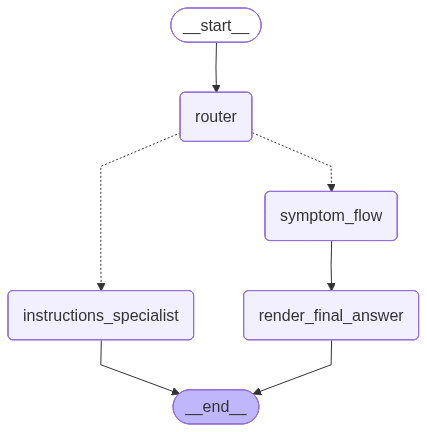

Patient: João P.
Profile: 67-year-old retired bus driver
Background: Lives with his spouse and recently attended a large family gathering.
Chronic conditions: type 2 diabetes, hypertension, hyperlipidemia
Current medications: metformin, losartan, atorvastatin
Allergies: no known drug allergies
Current context: Mentions reduced appetite and mild fatigue after a weekend with many relatives indoors.


In [10]:
show_graph_structure(demo_graph_v3)
print(render_active_patient_context(ACTIVE_PATIENT))

## Structured specialist smoke test

If the control-model endpoint is offline, this cell still validates the notebook-local specialist prompt, the GGUF invocation path, and the strict JSON contract.

In [11]:
specialist_smoke_result = symptom_invoker(
    "fever, dry cough, and fatigue for three days. what could this be and which exams would help?",
    render_active_patient_context(ACTIVE_PATIENT),
)

print(format_structured_payload(specialist_smoke_result))

{
  "support_status": "supported",
  "candidate_diseases": [
    "pneumonia"
  ],
  "recommended_exams_tests": [
    "complete blood count (CBC)",
    "X-ray"
  ]
}


## Symptom flow demo

This cell runs one symptom-oriented request through the full graph and surfaces the final structured result plus the final control-model answer.

In [12]:
symptom_question = "fever, dry cough, and fatigue for three days. what could this be and which exams would help?"
symptom_result: NotebookState | None = None
symptom_failure: dict[str, str] | None = None

try:
    symptom_result = cast(
        NotebookState,
        demo_graph_v3.invoke(create_initial_state(symptom_question, ACTIVE_PATIENT_KEY)),
    )
    describe_run_result(symptom_result)
except Exception as error:
    symptom_failure = {
        "question": symptom_question,
        "error_type": type(error).__name__,
        "error": str(error),
    }
    symptom_failure

Router response: destination='symptom_flow' rationale='The user is asking about symptoms and potential exams, which aligns with the symptom_flow destination.'


## Instructions flow demo

This cell runs one instructions-oriented request through the graph and keeps the result in standard LangChain message history.

In [13]:
instructions_question = "How should I describe my symptoms so this assistant can help me better?"
instructions_result: NotebookState | None = None
instructions_failure: dict[str, str] | None = None

try:
    instructions_result = cast(
        NotebookState,
        demo_graph_v3.invoke(create_initial_state(instructions_question, ACTIVE_PATIENT_KEY)),
    )
    describe_run_result(instructions_result)
except Exception as error:
    instructions_failure = {
        "question": instructions_question,
        "error_type": type(error).__name__,
        "error": str(error),
    }
    instructions_failure

Router response: destination='instructions_specialist' rationale='The user is asking for guidance on how to describe their symptoms effectively.'


## Conversation history

The next cells print the final LangChain message history for each run using the built-in `pretty_print()` representation.

In [14]:
if symptom_result is None:
    print("Symptom run did not complete; no history to display.")
else:
    for message in symptom_result["messages"]:
        message.pretty_print()

================================ Human Message =================================

fever, dry cough, and fatigue for three days. what could this be and which exams would help?
================================== Ai Message ==================================

<tool_call>[{"name": "run_symptom_specialist", "parameters": {"clinical_request": "fever, dry cough, and fatigue for three days. what could this be and which exams would help?", "active_patient_context": "Patient: João P. Profile: 67-year-old retired bus driver Background: Lives with his spouse and recently attended a large family gathering. Chronic conditions: type 2 diabetes, hypertension, hyperlipidemia Current medications: metformin, losartan, atorvastatin Allergies: no known drug allergies Current context: Mentions reduced appetite and mild fatigue after a weekend with many relatives indoors."}}]</tool_call>
Tool Calls:
  run_symptom_specialist (d0mjyFWje)
 Call ID: d0mjyFWje
  Args:
    clinical_request: fever, dry cough, and f

In [15]:
if instructions_result is None:
    print("Instructions run did not complete; no history to display.")
else:
    for message in instructions_result["messages"]:
        message.pretty_print()

================================ Human Message =================================

How should I describe my symptoms so this assistant can help me better?
================================== Ai Message ==================================

To help the assistant understand your symptoms better, provide these key details:

1. **What Symptoms Do You Have?** - Describe them clearly and concisely.
2. **When Did They Start?** - Include any recent changes or triggers.
3. **How Often Do They Occur?** - Are they constant or occasional?
4. **Severity** - Rate them from mild to severe.
5. **Associated Symptoms** - Any other issues that come with them.
6. **Age Range** - Your age helps in understanding typical patterns.
7. **Medical History** - Any past conditions or treatments.

For example: "I'm 35 years old. I started feeling a persistent headache last week after a stressful meeting at work. It's moderate in severity and occurs every day. I also feel nauseous sometimes. I've had migraines before bu